In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("student-por.csv", sep=";")


In [26]:
df1 = df.copy()

In [24]:
df1.drop(columns=["school"], inplace=True)

In [27]:
df["school"]

KeyError: 'school'

In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
from sklearn.model_selection import train_test_split


In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
# Target variable G3 (final grade)
y = df["G3"]
X = df.drop(columns=["G3", "G1", "G2"], axis=1)

In [7]:
X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0


In [8]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns

In [11]:
ordinal_variables = ["Medu", "Fedu", "traveltime", "studytime", "failures", "famrel", "freetime", "goout", "Dalc", "Walc", "health"]
nominal_variables = [col for col in categorical_cols if col not in ordinal_variables]

In [12]:
nominal_variables

['school',
 'sex',
 'address',
 'famsize',
 'Pstatus',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic']

In [13]:
# For the nominal and ordinal variables, use OneHotEncoding and OrdinalEncoding respectively.
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder


preprocessor = ColumnTransformer(
    transformers=[
        ('nominal', OneHotEncoder(sparse_output=False), nominal_variables),
        ('ordinal', OrdinalEncoder(), ordinal_variables)
    ]
)

X_transformed = preprocessor.fit_transform(df)

feature_names = preprocessor.get_feature_names_out()

X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)



In [15]:
X_transformed_df

,nominal__school_GP,nominal__school_MS,nominal__sex_F,nominal__sex_M,nominal__address_R,nominal__address_U,nominal__famsize_GT3,nominal__famsize_LE3,nominal__Pstatus_A,nominal__Pstatus_T,...,ordinal__Fedu,ordinal__traveltime,ordinal__studytime,ordinal__failures,ordinal__famrel,ordinal__freetime,ordinal__goout,ordinal__Dalc,ordinal__Walc,ordinal__health
0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,4.0,1.0,1.0,0.0,3.0,2.0,3.0,0.0,0.0,2.0
1,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,4.0,2.0,2.0,0.0,0.0,2.0
2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,3.0,2.0,1.0,1.0,2.0,2.0
3,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,2.0,0.0,2.0,0.0,2.0,1.0,1.0,0.0,0.0,4.0
4,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,3.0,0.0,1.0,0.0,3.0,2.0,1.0,0.0,1.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,3.0,0.0,2.0,1.0,4.0,3.0,1.0,0.0,1.0,4.0
645,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,3.0,2.0,3.0,0.0,0.0,0.0
646,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
647,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,3.0,4.0,2.0,3.0,1.0


In [17]:
# 6.	Implement correlation analysis. 
correlation_matrix = X_transformed_df.corr()

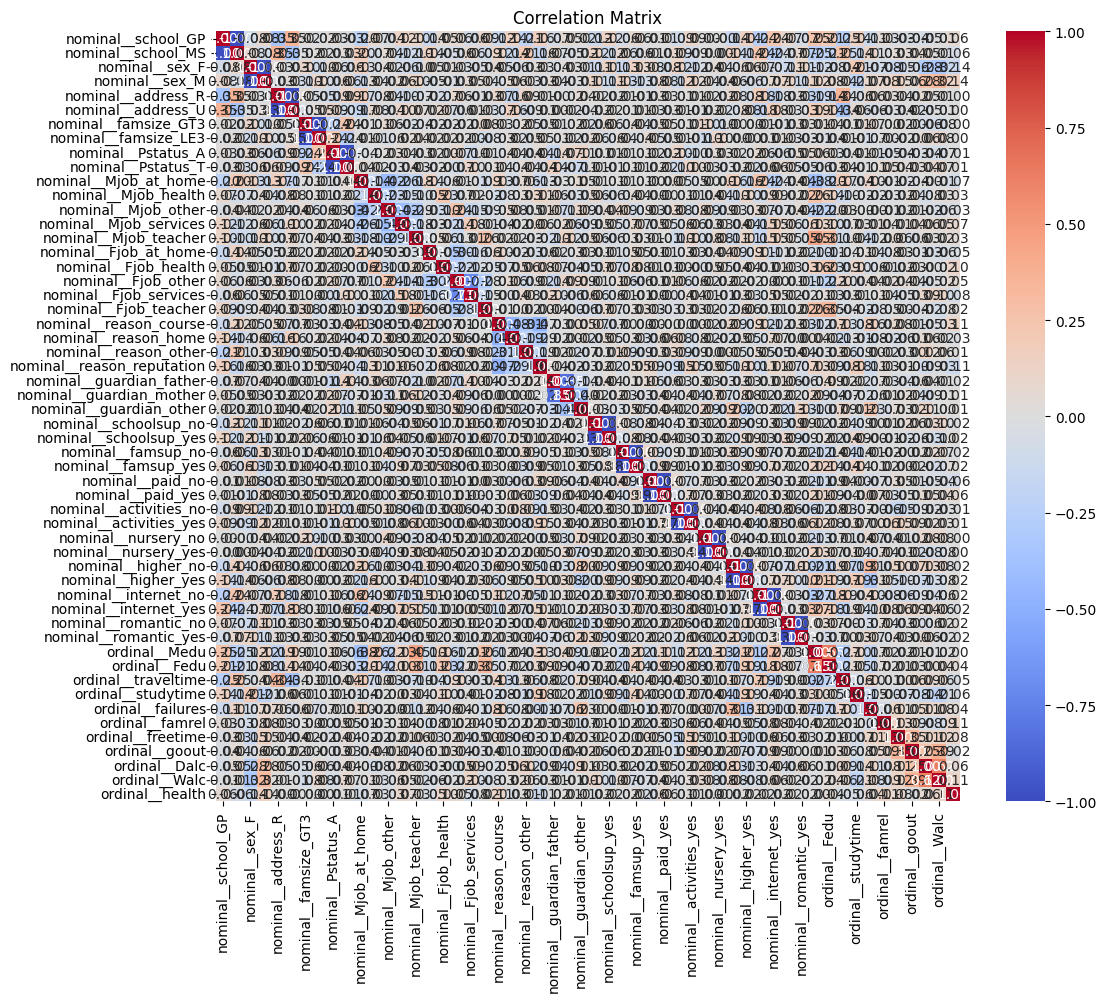

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [28]:
# 7.	Implement linear regression and report R2, adjusted R2*, and RMSE. 

linear_model = LinearRegression()
linear_model.fit(X_transformed, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
from sklearn.metrics import r2_score, mean_squared_error
r2 = r2_score(y, linear_model.predict(X_transformed_df))
rmse = mean_squared_error(y, linear_model.predict(X_transformed_df))
n = X_transformed_df.shape[0]
p = X_transformed_df.shape[1]
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adjusted_r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R2: 0.3557
Adjusted R2: 0.2971
RMSE: 6.7148


/Users/manuel/Documents/UNF/Predictive Analytics/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/Users/manuel/Documents/UNF/Predictive Analytics/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [30]:
y_pred = linear_model.predict(X_transformed_df)

/Users/manuel/Documents/UNF/Predictive Analytics/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
